## **Tipos de regresión**
* Lineal (simple y múltiple)
* Polinómica
* Logística

---

## **Regresión Lineal Simple**

* Modela la relación entre $x$ e $y$ **utilizando una línea recta**:

$$y = mx + b$$

* $m \rightarrow$ pendiente de la recta  
* $b \rightarrow$ es la intersección con el eje $y$  
* $x \rightarrow$ variable independiente  
* $y \rightarrow$ variable dependiente

---

Para este ejemplo, usaremos estos datos hipotéticos:
* Horas ($x$): $[1, 2, 3, 4, 5]$
* Calificaciones ($y$): $[40, 50, 60, 70, 80]$ (Donde la relación es $y = 10x + 30$)

---

**1. Nivel Nativo (Python puro)**

Aquí calculamos la pendiente ($m$) y la intersección ($b$) usando fórmulas estadísticas (Mínimos Cuadrados Ordinarios).


In [ ]:
x = [1, 2, 3, 4, 5]
y = [40, 50, 60, 70, 80]

n = len(x)
sum_x = sum(x)
sum_y = sum(y)
sum_xy = sum(xi*yi for xi, yi in zip(x, y))
sum_x_sq = sum(xi**2 for xi in x)

# Fórmula para m y b (⚒️)
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x_sq - sum_x**2)
b = (sum_y - m * sum_x) / n

print(f"Ecuación: y = {m}x + {b}")

Ecuación: y = 10.0x + 30.0


In [ ]:
# Datos de entrenamiento
x_train = [1, 2, 3, 4, 5]
y_train = [40, 50, 60, 70, 80]

# Entrenamiento (Cálculo de m y b)
n = len(x_train)
m = (n * sum(xi*yi for xi, yi in zip(x_train, y_train)) - sum(x_train) * sum(y_train)) / (n * sum(xi**2 for xi in x_train) - sum(x_train)**2)
b = (sum(y_train) - m * sum(x_train)) / n

# Predicción para un nuevo valor (6 horas)
nuevo_x = 6
prediccion = m * nuevo_x + b

print(f"Predicción para {nuevo_x} horas: {prediccion}")

Predicción para 6 horas: 90.0


---
**2. TensorFlow (Nivel Bajo)**

En TensorFlow "puro", definimos las variables y optimizamos una función de pérdida (MSE) manualmente mediante el descenso de gradiente.

In [ ]:
import tensorflow as tf

x = tf.constant([1.0, 2.0, 3.0, 4.0, 5.0])
y = tf.constant([40.0, 50.0, 60.0, 70.0, 80.0])

m = tf.Variable(0.0)
b = tf.Variable(0.0)

opt = tf.optimizers.SGD(learning_rate=0.01)

for i in range(1000):
    with tf.GradientTape() as tape:
        y_pred = m * x + b
        loss = tf.reduce_mean(tf.square(y - y_pred))
    grads = tape.gradient(loss, [m, b])
    opt.apply_gradients(zip(grads, [m, b]))

print(f"m: {m.numpy()}, b: {b.numpy()}")

m: 10.236907958984375, b: 29.14468765258789


In [ ]:
import tensorflow as tf

# Datos
x = tf.constant([1., 2., 3., 4., 5.])
y = tf.constant([40., 50., 60., 70., 80.])

m = tf.Variable(0.0)
b = tf.Variable(0.0)
opt = tf.optimizers.SGD(learning_rate=0.01)

# Ciclo de entrenamiento
for _ in range(1000):
    with tf.GradientTape() as tape:
        y_pred = m * x + b
        loss = tf.reduce_mean(tf.square(y - y_pred)) # Error Cuadrático Medio
    grads = tape.gradient(loss, [m, b])
    opt.apply_gradients(zip(grads, [m, b]))

# Cálculo de nuevo valor
nuevo_x = 6.0
prediccion = m * nuevo_x + b
print(f"Predicción para {nuevo_x} horas: {prediccion.numpy():.2f}")

Predicción para 6.0 horas: 90.57


---
**3. Keras (Nivel Alto/Deep Learning)**

Keras simplifica todo tratando la regresión como una red neuronal de una sola capa con una sola neurona.

In [ ]:
from tensorflow import keras
import numpy as np

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([40, 50, 60, 70, 80], dtype=float)

model = keras.Sequential([
    keras.Input(shape=(1,)), # Define explícitamente la forma de entrada
    keras.layers.Dense(units=1)
])
model.compile(optimizer='sgd', loss='mean_squared_error')

model.fit(x, y, epochs=500, verbose=0)

print(f"Predicción para 6 horas: {model.predict(np.array([6.0], dtype=float))}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicción para 6 horas: [[93.048965]]


In [ ]:
from tensorflow import keras
import numpy as np

x_train = np.array([1, 2, 3, 4, 5], dtype=float)
y_train = np.array([40, 50, 60, 70, 80], dtype=float)

# Definir y entrenar
model = keras.Sequential([
    keras.Input(shape=(1,)), # Define explícitamente la forma de entrada
    keras.layers.Dense(units=1)
])
model.compile(optimizer='sgd', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=500, verbose=0) # Entrenando...

# Calcular nuevo valor
nuevo_x = np.array([6.0])
prediccion = model.predict(nuevo_x)
print(f"Predicción para 6 horas: {prediccion[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicción para 6 horas: 93.11


---

**4. Scikit-Learn (Nivel Científico/Analítico)**

Es la forma más estándar y eficiente para Machine Learning tradicional. No requiere iteraciones manuales ni definición de optimizadores.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1) # Necesita matriz 2D
y = np.array([40, 50, 60, 70, 80])

model = LinearRegression()
model.fit(x, y)

print(f"Pendiente (m): {model.coef_[0]}")
print(f"Intersección (b): {model.intercept_}")

Pendiente (m): 9.999999999999998
Intersección (b): 30.000000000000007


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Datos (Scikit-learn requiere que X sea una matriz de 2 dimensiones)
x_train = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_train = np.array([40, 50, 60, 70, 80])

# Entrenamiento
modelo = LinearRegression()
modelo.fit(x_train, y_train)

# Calcular nuevo valor
nuevo_x = np.array([[6]])
prediccion = modelo.predict(nuevo_x)

print(f"Predicción para 6 horas: {prediccion[0]:.2f}")

Predicción para 6 horas: 90.00


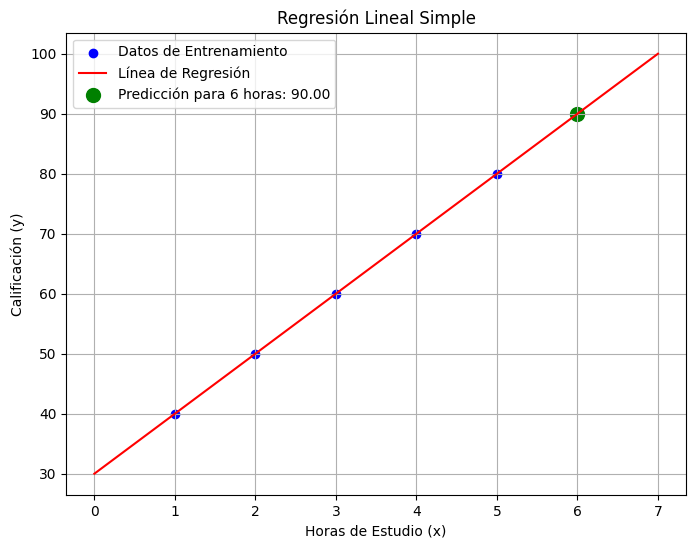

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Datos (obtenidos de una celda anterior)
x_train = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_train = np.array([40, 50, 60, 70, 80])

# Entrenamiento del modelo (obtenido de una celda anterior)
modelo = LinearRegression()
modelo.fit(x_train, y_train)

# Generar puntos para la línea de regresión
x_line = np.array([0, 7]).reshape(-1, 1) # Rango de x para graficar la línea
y_line = modelo.predict(x_line)

# Nuevo valor para predicción
nuevo_x = np.array([[6]])
prediccion = modelo.predict(nuevo_x)

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', label='Datos de Entrenamiento')
plt.plot(x_line, y_line, color='red', label='Línea de Regresión')
plt.scatter(nuevo_x, prediccion, color='green', marker='o', s=100, label=f'Predicción para {nuevo_x[0][0]} horas: {prediccion[0]:.2f}')

plt.title('Regresión Lineal Simple')
plt.xlabel('Horas de Estudio (x)')
plt.ylabel('Calificación (y)')
plt.grid(True)
plt.legend()
plt.show()